In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
env_desc = [
    "FFHF",
    "FHGH",
    "HFFF",
    "FFSH"
]

env = gym.make("FrozenLake-v1", desc=env_desc, is_slippery=True)
num_states = env.observation_space.n
num_actions = env.action_space.n

In [ ]:
num_episodes = 10000
learning_rate = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.9995
epsilon_min = 0.01




In [ ]:
Q = np.zeros((num_states, num_actions))
def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    return int(np.argmax(Q[state]))

In [ ]:


episode_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = choose_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)

        # Q-learning target: reward + gamma * max_a Q(next_state, a)
        if terminated or truncated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        Q[state, action] += learning_rate * (target - Q[state, action])

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

# Extract the greedy value function and policy after training.
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)

In [ ]:
def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)

In [ ]:

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.182 0.398 0.204 0.134]
 [0.705 0.454 0.486 0.346]
 [0.104 0.109 0.112 0.225]
 [0.307 0.54  0.307 0.365]
 [0.451 0.575 0.492 0.487]
 [0.616 0.376 0.276 0.285]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.    0.398 0.705 0.225]
 [0.54  0.575 0.616 0.   ]]

Learned Policy:
[['L' 'L' 'L' 'L']
 ['L' 'L' 'L' 'L']
 ['L' 'D' 'L' 'U']
 ['D' 'D' 'L' 'L']]

Average reward over last 1000 episodes: 0.664


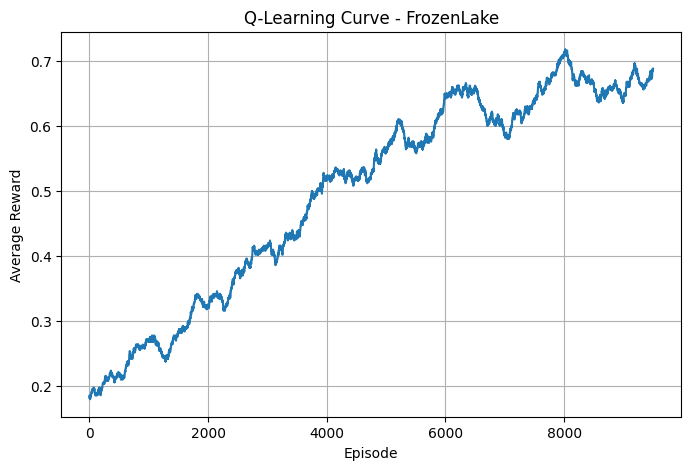

In [ ]:
window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()